# NTK visualization
This notebook aims to compare the **empirical** Neural Tangent Kernel of different architectures. 

Architectures analysed:
- Base Kernel (just the MLP)
- PINN
- Fourier Features
- SIRENs

plus the **infinite-width** deterministic NTK ($\Theta_\infty$) of the MLP as a reference limit.

We'll consider functions which maps to an unidimensional space to ease the visualisation

## Setup

In [87]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig, TrainingConfig
from src.SIRENs import SIREN, SIRENConfig
from src.spectral_analysis import compute_ntk
from src.numerical_solvers import rk4_solve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/ntk-nn/figures
Device: mps


In [88]:
class ForcedFirstOrderODE:
    """
    z' = sum_k A_k sin(2*pi*f_k*t + phi_k)
    """

    def __init__(self, freqs, amps, phases):
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [self._forcing(t, np.sin)]

    def rhs_torch(self, t, z):
        return self._forcing(t, torch.sin)

Grid: 500 points on [0, 2.0]


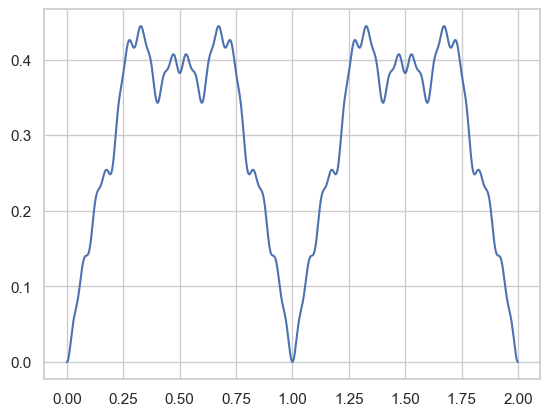

In [130]:
# ODE parameters
FREQS = [1.0, 2.0, 5.0, 10.0, 20.0]
AMPS = [1.0, 1.0, 1.0, 1.0, 1.0]
PHASES = [0, 0, 0, 0, 0]

# Decay rate of the ODE  z' = -ALPHA*z + F(t).  ForcedFirstOrderODE.rhs returns the
# forcing F(t) only (no z-dependence), so this notebook studies the forcing-only case
# ALPHA = 0 — the PINN residual operator then reduces to ∂_t.
ALPHA = 0.0

T     = 2.0
N_GRID = 500

t_eval = np.linspace(0, T, N_GRID, dtype=np.float32)
print(f"Grid: {N_GRID} points on [0, {T}]")

ode    = ForcedFirstOrderODE(FREQS, AMPS, PHASES)

y_fitted = rk4_solve(ode.rhs_np, [0], t_eval)

plt.plot(t_eval, y_fitted)
plt.show()

## Architecture Definitions

In [131]:
# --- Instantiate all architectures at random initialisation ---
WIDTH, DEPTH = 32, 3
SIREN_OMEGA = 20

FF_SIGMA = 10.0
FF_N_FREQS = 16
rng = np.random.default_rng()
FOURIER_FREQS = rng.normal(loc=0.0, scale=FF_SIGMA, size=(FF_N_FREQS,))

mlp     = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH)).to(DEVICE)
fourier = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH, fourier_freqs=FOURIER_FREQS)).to(DEVICE)
siren   = SIREN(SIRENConfig(n_vars=1, width=WIDTH, depth=DEPTH, omega_0=SIREN_OMEGA)).to(DEVICE)

MODELS = {
    "MLP (Tanh)":  mlp,
    "Fourier MLP": fourier,
    "SIREN":       siren,
}

print(f"{'Architecture':<20} {'Params':>10}")
print("-" * 32)
for name, m in MODELS.items():
    P = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} {P:>10,}")

Architecture             Params
--------------------------------
MLP (Tanh)                1,153
Fourier MLP               2,177
SIREN                     1,153


In [132]:
print("Computing NTK matrices at random initialisation...")
print(f"  Grid: {len(t_eval)} points  |  arch width={WIDTH}, depth={DEPTH}\n")

ntk_matrices    = {}
ntk_eigenvalues = {}
ntk_eigenvectors = {}

for name, model in MODELS.items():
    print(f"  {name}...", end=" ", flush=True)
    K = compute_ntk(model, t_eval, device=DEVICE)
    vals, vecs = np.linalg.eigh(K)
    ntk_matrices[name]     = K
    ntk_eigenvalues[name]  = vals[::-1].copy()
    ntk_eigenvectors[name] = vecs[:, ::-1].copy()
    eff_rank = int((vals.sum() ** 2) / (vals ** 2).sum())   # participation ratio
    print(f"λ_max={vals[-1]:.2e}  λ_min={vals[vals > 0].min():.2e}  eff_rank≈{eff_rank}")

# PINN NTK: same MLP backbone but Jacobian is ∂R/∂θ instead of ∂f/∂θ
print(f"  PINN NTK (K_ff)...", end=" ", flush=True)
K_pinn = mlp.ntk(t_eval, ode.rhs_torch, device=DEVICE)
vals_p, vecs_p = np.linalg.eigh(K_pinn)
ntk_matrices["PINN NTK"]     = K_pinn
ntk_eigenvalues["PINN NTK"]  = vals_p[::-1].copy()
ntk_eigenvectors["PINN NTK"] = vecs_p[:, ::-1].copy()
eff_rank_p = int((vals_p.sum() ** 2) / (vals_p ** 2).sum())
print(f"λ_max={vals_p[-1]:.2e}  λ_min={vals_p[vals_p > 0].min():.2e}  eff_rank≈{eff_rank_p}")

ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

Computing NTK matrices at random initialisation...
  Grid: 500 points  |  arch width=32, depth=3

  MLP (Tanh)... λ_max=3.57e+03  λ_min=7.87e-08  eff_rank≈1
  Fourier MLP... λ_max=9.60e+02  λ_min=3.50e-09  eff_rank≈5
  SIREN... λ_max=7.31e+04  λ_min=5.31e-06  eff_rank≈14
  PINN NTK (K_ff)... λ_max=1.23e+03  λ_min=4.56e-08  eff_rank≈1


## Visualizations

### NTK Heatmaps

`K[i, j]` measures how correlated the gradient directions are at inputs `t_i` and `t_j`.
A kernel concentrated along the diagonal indicates localised representations; off-diagonal mass
indicates that learning at one point affects many others.
Each matrix is normalised by its maximum value for comparability.

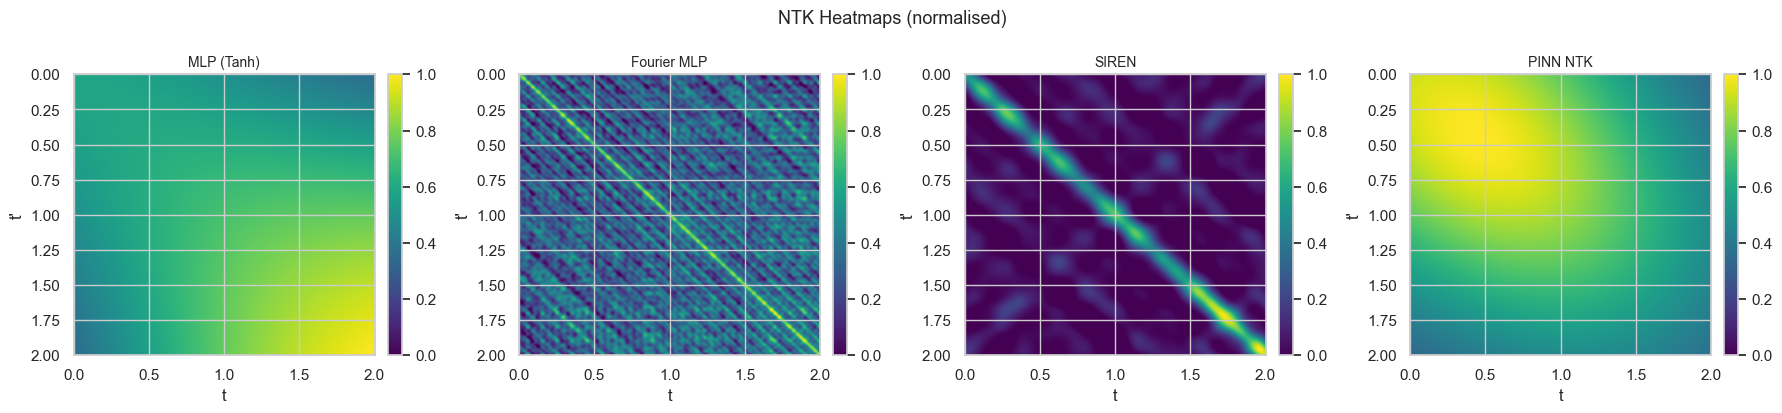

In [133]:
N = len(ARCH_NAMES)
fig, axes = plt.subplots(1, N, figsize=(4.5 * N, 4.2))
fig.suptitle("NTK Heatmaps (normalised)", fontsize=13)

for ax, name in zip(axes, ARCH_NAMES):
    K     = ntk_matrices[name]
    K_vis = K / K.max()
    im = ax.imshow(
        K_vis, cmap="viridis", aspect="auto",
        extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]],
        vmin=0, vmax=1,
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("t")
    ax.set_ylabel("t'")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Kernel slice  k(t, t★)

Fixing one argument at a centre point `t★` and varying the other gives a 1-D cross-section of
the kernel. Its width and shape reveal how far the influence of a single training point spreads:
a narrow peak → localised, independent representations; a broad or oscillatory profile →
long-range correlations across the input domain.
Slices are normalised by `k(t★, t★)` so they all start at 1 and are directly comparable.

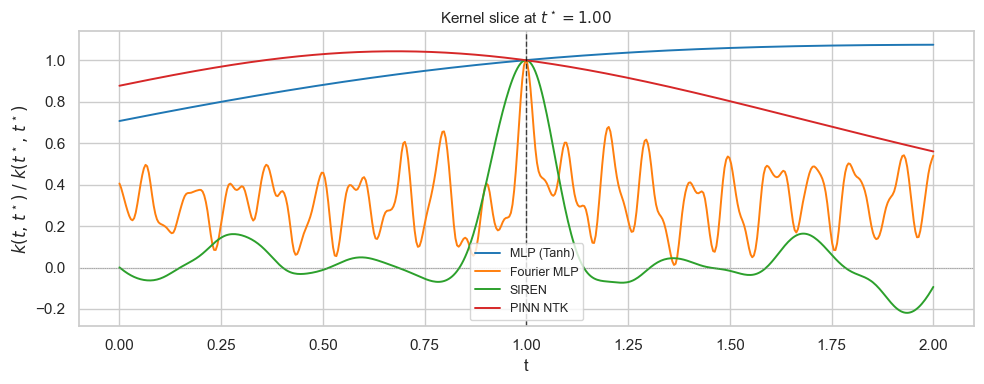

In [134]:
T_STAR = 1.0
center_idx   = np.argmin(np.abs(t_eval - T_STAR))
t_star_actual = float(t_eval[center_idx])

fig, ax = plt.subplots(figsize=(10, 4))

for name in ARCH_NAMES:
    K     = ntk_matrices[name]
    slice_ = K[:, center_idx] / K[center_idx, center_idx]   # normalise so k(t★, t★) = 1
    ax.plot(t_eval, slice_, label=name, color=PALETTE[name], linewidth=1.4)

ax.axvline(t_star_actual, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("t")
ax.set_ylabel(r"$k(t,\, t^\star)\;/\; k(t^\star,\, t^\star)$")
ax.set_title(f"Kernel slice at $t^\\star = {t_star_actual:.2f}$", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_kernel_slice.png", dpi=150, bbox_inches="tight")
plt.show()

### Eigenvalue Spectra

Under gradient-flow, the projection of the error onto the `k`-th NTK eigenvector decays at rate
`exp(-η λ_k t)`. Architectures with a flatter spectrum (slower eigenvalue decay) converge more
uniformly across frequencies — less spectral bias.

The **cumulative trace fraction** shows what share of the total learning speed is concentrated
in the top-k eigenmodes (effective rank).

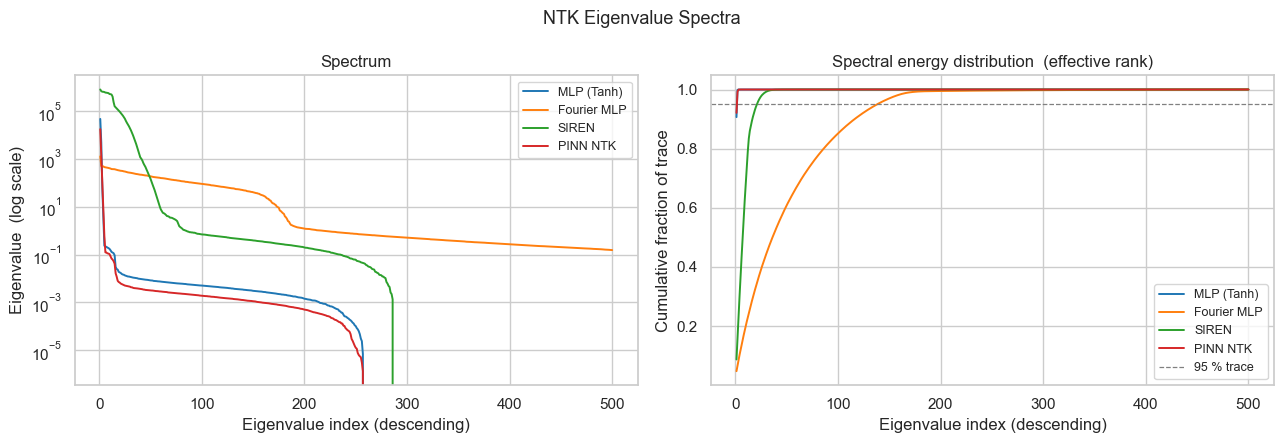

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("NTK Eigenvalue Spectra", fontsize=13)

idx = np.arange(1, len(t_eval) + 1)

ax = axes[0]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    ax.semilogy(idx, vals, label=name, color=PALETTE[name], linewidth=1.4)
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Eigenvalue  (log scale)")
ax.set_title("Spectrum")
ax.legend(fontsize=9)

ax = axes[1]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    cum  = np.cumsum(vals) / vals.sum()
    ax.plot(idx, cum, label=name, color=PALETTE[name], linewidth=1.4)
ax.axhline(0.95, color="gray", linestyle="--", linewidth=0.9, label="95 % trace")
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Cumulative fraction of trace")
ax.set_title("Spectral energy distribution  (effective rank)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

## Infinite-width limit (deterministic NTK)

The kernels above are *empirical* — single random draws at finite width. As width $\to\infty$ the
(standard-parametrisation) NTK of the plain MLP converges to a **deterministic** kernel $\Theta_\infty$
given by the NNGP/NTK recursion (Jacot et al. 2018):

$$\Sigma^{(1)} = \sigma_w^2\,\tfrac{x\cdot x'}{d} + \sigma_b^2,\quad
\Sigma^{(l+1)} = \sigma_w^2\,\mathbb{E}[\sigma(u)\sigma(v)] + \sigma_b^2,\quad
\Theta^{(l+1)} = \Sigma^{(l+1)} + \Theta^{(l)}\,\sigma_w^2\,\mathbb{E}[\sigma'(u)\sigma'(v)].$$

For tanh the Gaussian expectations have no closed form, so we evaluate them by 2-D Gauss–Hermite
quadrature. We add $\Theta_\infty$ next to the empirical MLP as a **reference**: the finite MLP NTK is
already within a few percent of it (correlation form), so the near-rank-1 structure and low-frequency
eigenvectors you see for the MLP are properties of the *limit*, not of finite width.

> NTK magnitude is parametrisation-dependent; we rescale $\Theta_\infty$ so its top eigenvalue matches the
> empirical MLP for the spectrum overlay (heatmaps and slices are normalised anyway).

In [95]:
# ── Infinite-width NTK via the NNGP/NTK recursion (tanh, Gauss–Hermite) ────────
SW2_INF, SB2_INF = 1.0, 0.2          # chosen to match this notebook's default-init MLP
_GH = 20
_ghx, _ghw = np.polynomial.hermite.hermgauss(_GH)
_ghx = np.sqrt(2.0) * _ghx
_ghw = _ghw / np.sqrt(np.pi)

def _tanh_expectations(var, Cov):
    """E[σ(u)σ(v)] and E[σ'(u)σ'(v)] for (u,v)~N(0,Λ), elementwise over a grid (tanh)."""
    sd = np.sqrt(np.clip(var, 1e-30, None))
    rho = np.clip(Cov / np.outer(sd, sd), -1.0, 1.0)
    comp = np.sqrt(np.clip(1.0 - rho ** 2, 0.0, None))
    Ess = np.zeros_like(Cov); Edd = np.zeros_like(Cov)
    for p in range(_GH):
        u = sd[:, None] * _ghx[p]; tu = np.tanh(u); du = 1.0 - tu ** 2
        for q in range(_GH):
            v = sd[None, :] * (rho * _ghx[p] + comp * _ghx[q]); w = _ghw[p] * _ghw[q]
            Ess += w * tu * np.tanh(v)
            Edd += w * du * (1.0 - np.tanh(v) ** 2)
    return (Ess + Ess.T) / 2.0, (Edd + Edd.T) / 2.0

def infinite_width_ntk(t, depth, sigma_w2=1.0, sigma_b2=0.2):
    """Deterministic NTK Θ_∞ of an infinitely wide tanh MLP with `depth` weight layers."""
    X = np.asarray(t, dtype=float).reshape(-1, 1)
    Sigma = sigma_w2 * (X @ X.T) + sigma_b2          # Σ^(1)
    Theta = Sigma.copy()                              # Θ^(1)
    for _ in range(depth - 1):
        Ess, Edd = _tanh_expectations(np.diag(Sigma).copy(), Sigma)
        Sigma = sigma_w2 * Ess + sigma_b2            # Σ^(l+1)
        Theta = Sigma + Theta * (sigma_w2 * Edd)     # Θ^(l+1)
    return Theta

def _corr(K):
    d = np.sqrt(np.diag(K).clip(0)); d = np.where(d == 0, 1.0, d); return K / np.outer(d, d)

INF_NAME = "MLP ∞-width (Θ∞)"
print("Computing infinite-width NTK (tanh, depth %d)..." % DEPTH, flush=True)
K_inf_raw = infinite_width_ntk(t_eval, DEPTH, SW2_INF, SB2_INF)
# rescale so λ_max matches the empirical MLP (NTK scale is parametrisation-dependent)
lam_inf_max = np.linalg.eigvalsh(K_inf_raw)[-1]
K_inf = K_inf_raw * (ntk_eigenvalues["MLP (Tanh)"][0] / lam_inf_max)

vals_inf, vecs_inf = np.linalg.eigh(K_inf)
ntk_matrices[INF_NAME]     = K_inf
ntk_eigenvalues[INF_NAME]  = vals_inf[::-1].copy()
ntk_eigenvectors[INF_NAME] = vecs_inf[:, ::-1].copy()

rel = (np.linalg.norm(_corr(K_inf) - _corr(ntk_matrices["MLP (Tanh)"]))
       / np.linalg.norm(_corr(ntk_matrices["MLP (Tanh)"])))
eff_rank_inf = int((vals_inf.sum() ** 2) / (vals_inf ** 2).sum())
print(f"  Θ∞  eff_rank≈{eff_rank_inf}   |  corr-distance to finite MLP NTK = {rel:.3f}")

# Re-order so Θ∞ sits next to the empirical MLP, then refresh the shared lookups
_order = ["MLP (Tanh)", INF_NAME, "Fourier MLP", "SIREN", "PINN NTK"]
ntk_matrices     = {k: ntk_matrices[k]     for k in _order}
ntk_eigenvalues  = {k: ntk_eigenvalues[k]  for k in _order}
ntk_eigenvectors = {k: ntk_eigenvectors[k] for k in _order}
ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

Computing infinite-width NTK (tanh, depth 3)...
  Θ∞  eff_rank≈1   |  corr-distance to finite MLP NTK = 0.030


## Infinite-width kernels for every architecture

We computed $\Theta_\infty$ for the plain MLP above. The same machinery extends to the others — each
architecture changes exactly **one** stage of the NNGP/NTK recursion:

- **Fourier MLP** — the embedding is a *fixed* map, so seed the recursion with the embedding Gram
  $\gamma(t)\cdot\gamma(t') = \sum_k\cos\!\big(2\pi f_k(t-t')\big) + t\,t'$ instead of the raw dot product, then
  run the same tanh recursion. (Already multi-mode → high effective rank, before the MLP even acts.)
- **SIREN** — replace tanh by sin: the Gaussian expectations are closed-form,
  $\mathbb{E}[\sin u\,\sin v]=e^{-(a+b)/2}\sinh c$ and $\mathbb{E}[\sin' u\,\sin' v]=e^{-(a+b)/2}\cosh c$.
  The $\omega_0=30$ scaling makes the first-layer variance $O(\omega_0^2)$, so we use the numerically-stable
  form — Gauss–Hermite quadrature is unreliable at that scale (it mis-integrates the rapid oscillations).
- **PINN** — apply the linear operator to the backbone limit:
  $\Theta_{\mathrm{PINN}}^{\infty} = (\partial_t+\alpha)(\partial_{t'}+\alpha)\,\Theta_\infty$.

These are the deterministic limits the finite kernels approach. We report the correlation-form distance to
each empirical kernel below; the $\omega_0=30$ SIREN converges slowly with width, so its match is the loosest
(but the effective rank and localisation length are right).

In [98]:
# ── Infinite-width kernels for Fourier, SIREN, PINN (reuses _tanh_expectations) ─
def _sincos_expectations(var, Cov):
    """E[sin u sin v]=e^{-(a+b)/2}sinh(c) and E[sin'u sin'v]=E[cos u cos v]=e^{-(a+b)/2}cosh(c),
    in overflow-safe form (SIREN pre-activation variances are O(ω₀²)).
    
    Parameters
    ----------
    
    
    """
    a = var[:, None]; b = var[None, :]; c = Cov
    half = (a + b) / 2.0
    Ess = 0.5 * (np.exp(c - half) - np.exp(-c - half))
    Ecc = 0.5 * (np.exp(c - half) + np.exp(-c - half))
    return Ess, Ecc

def _iw_tanh_from_base(Sigma1, depth, sigma_w2):
    """tanh NNGP/NTK recursion seeded from a given first-layer covariance Σ^(1)."""
    Sigma = Sigma1.copy(); Theta = Sigma.copy()
    for _ in range(depth - 1):
        Ess, Edd = _tanh_expectations(np.diag(Sigma).copy(), Sigma)
        Sigma = sigma_w2 * Ess
        Theta = Sigma + Theta * (sigma_w2 * Edd)
    return Theta

def infinite_width_fourier(t, freqs, depth, sigma_w2, sigma_b2):
    """Θ_∞ of a tanh MLP on a fixed Fourier embedding (base = embedding Gram)."""
    tt = np.asarray(t, float)
    cols = [np.sin(2*np.pi*f*tt) for f in freqs] + [np.cos(2*np.pi*f*tt) for f in freqs] + [tt]
    G = np.stack(cols, 1)
    Sigma1 = sigma_w2 * (G @ G.T) / G.shape[1] + sigma_b2
    return _iw_tanh_from_base(Sigma1, depth, sigma_w2)

def infinite_width_siren(t, depth, scale1, offset1, gw_hidden=2.0):
    """Θ_∞ of a SIREN (sin activation, closed-form expectations). scale1/offset1 are
    the effective first-layer pre-activation variance constants (∝ ω₀²·Var(W),Var(b))."""
    X = np.asarray(t, float).reshape(-1, 1)
    Lam = scale1 * (X @ X.T) + offset1
    Theta = Lam.copy()
    for _ in range(depth - 2):                              # hidden sin layers
        Ess, Ecc = _sincos_expectations(np.diag(Lam).copy(), Lam)
        Lam = gw_hidden * Ess
        Theta = Lam + Theta * (gw_hidden * Ecc)
    Ess, _ = _sincos_expectations(np.diag(Lam).copy(), Lam)  # linear readout
    return Ess + Theta

def apply_ode_operator(Theta, t, alpha):
    """(∂_t+α)(∂_{t'}+α) Θ by finite differences (the PINN ∞-width kernel)."""
    h = t[1] - t[0]
    d_t = np.gradient(Theta, h, axis=0); d_tp = np.gradient(Theta, h, axis=1)
    d_ttp = np.gradient(d_tp, h, axis=0)
    return d_ttp + alpha * d_t + alpha * d_tp + alpha ** 2 * Theta

# effective init constants (chosen to match this notebook's finite kernels)
SW2_F, SB2_F = 0.5, 0.05            # Fourier tanh layers
S1_S, S0_S   = 600.0, 300.0         # SIREN effective first-layer scale (≈ 2·ω₀²/3, ω₀=30)

K_inf_mlp     = ntk_matrices["MLP ∞-width (Θ∞)"]                       # from earlier cell
K_inf_fourier = infinite_width_fourier(t_eval, FOURIER_FREQS, DEPTH, SW2_F, SB2_F)
K_inf_siren   = infinite_width_siren(t_eval, DEPTH, S1_S, S0_S)
# residual operator is ∂_t only: the forcing-only rhs F(t) has no z-dependence ⇒ α = 0
K_inf_pinn    = apply_ode_operator(K_inf_mlp, t_eval, ALPHA)

# pair each empirical kernel with its infinite-width limit
INF_PAIRS = {
    "MLP (Tanh)":  (ntk_matrices["MLP (Tanh)"],  K_inf_mlp),
    "Fourier MLP": (ntk_matrices["Fourier MLP"], K_inf_fourier),
    "SIREN":       (ntk_matrices["SIREN"],       K_inf_siren),
    "PINN NTK":    (ntk_matrices["PINN NTK"],     K_inf_pinn),
}

def _eff_rank(K):
    w = np.linalg.eigvalsh(_corr(K)); w = w[w > 1e-12]; return w.sum() ** 2 / (w ** 2).sum()

sl = slice(2, -2)   # trim finite-difference edges (matters only for PINN)
print(f"{'architecture':<13} {'corr-dist':>9} {'eff_rank emp':>13} {'eff_rank Θ∞':>12}")
print("-" * 50)
for name, (K_emp, K_inf) in INF_PAIRS.items():
    cd = (np.linalg.norm(_corr(K_inf)[sl, sl] - _corr(K_emp)[sl, sl])
          / np.linalg.norm(_corr(K_emp)[sl, sl]))
    print(f"{name:<13} {cd:>9.3f} {_eff_rank(K_emp):>13.1f} {_eff_rank(K_inf):>12.1f}")

architecture  corr-dist  eff_rank emp  eff_rank Θ∞
--------------------------------------------------
MLP (Tanh)        0.030           1.2          1.2
Fourier MLP       1.211          92.6         30.3
SIREN             0.375          17.6         28.0
PINN NTK          0.339           1.2          1.9


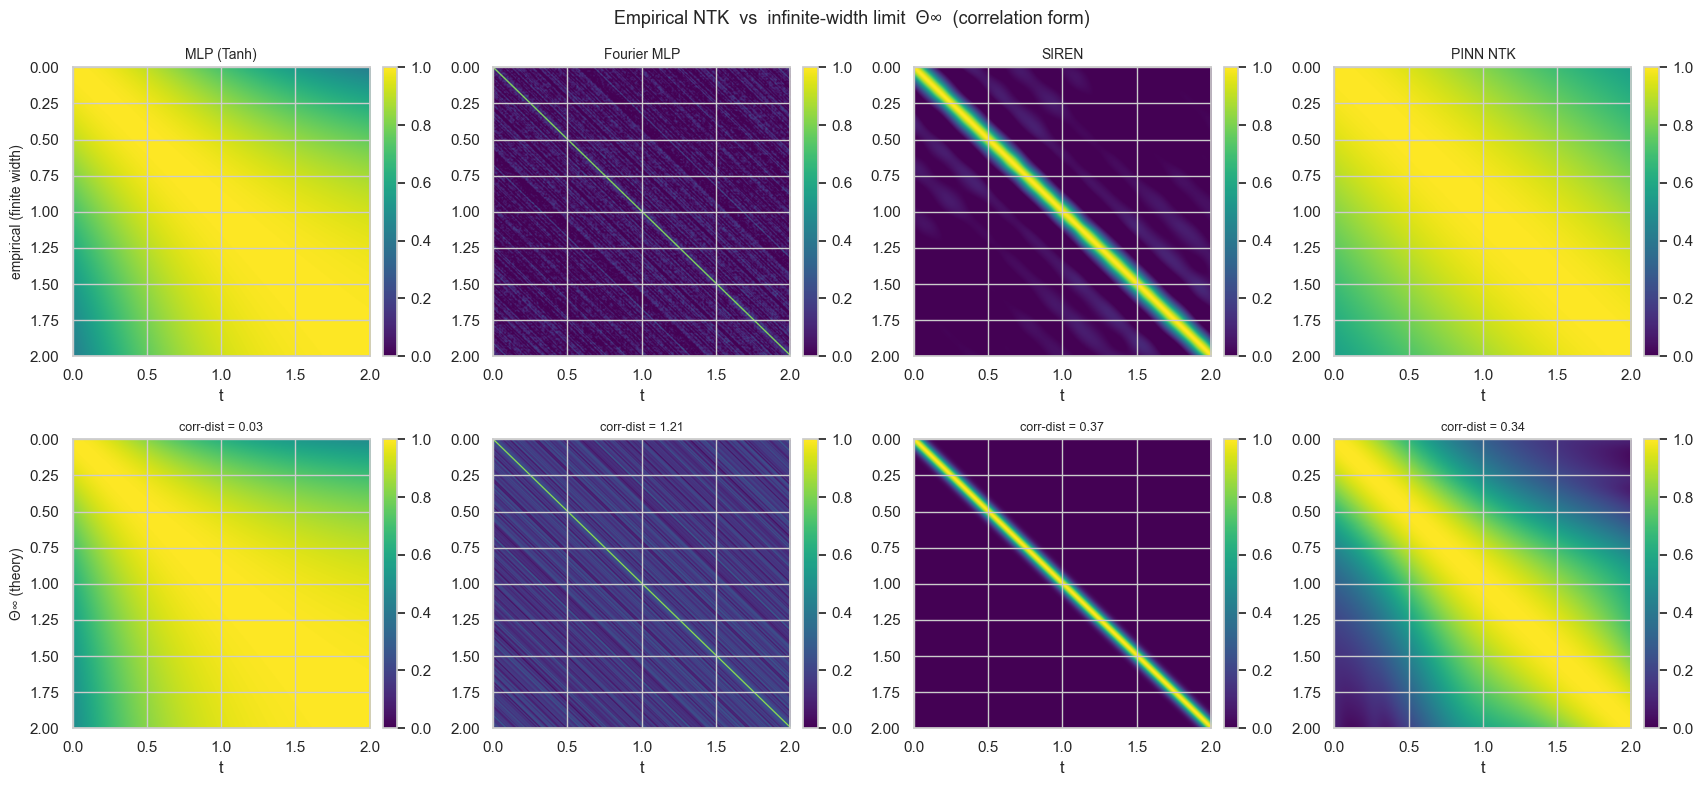

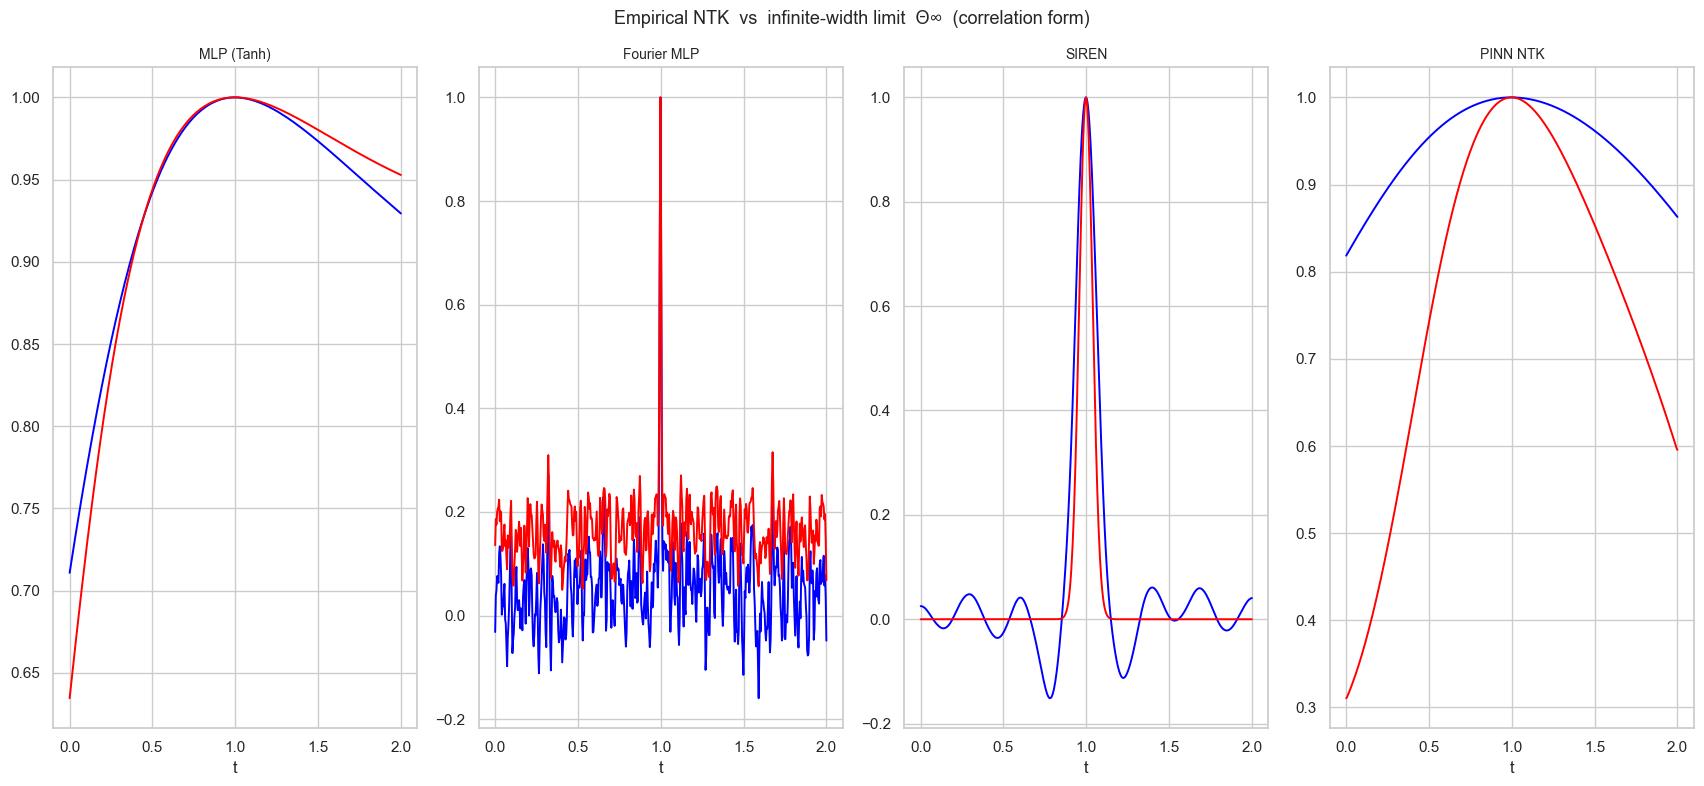

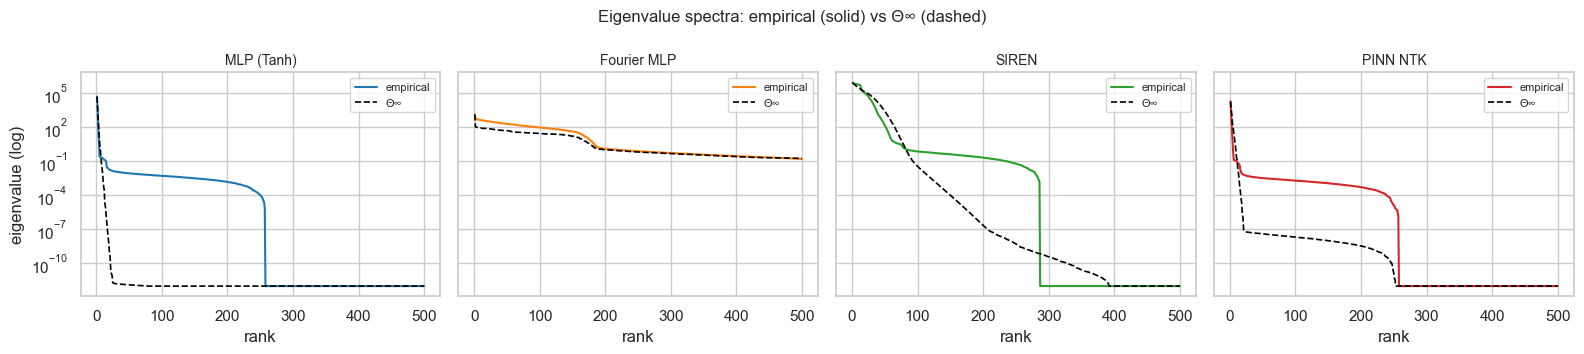

In [135]:
# ── Gallery: empirical NTK (top) vs infinite-width Θ_∞ (bottom), correlation form ─
names = list(INF_PAIRS.keys())
fig, axes = plt.subplots(2, len(names), figsize=(4.3 * len(names), 8))
fig.suptitle("Empirical NTK  vs  infinite-width limit  Θ∞  (correlation form)", fontsize=13)
axes[0, 0].set_ylabel("empirical (finite width)", fontsize=10)
axes[1, 0].set_ylabel("Θ∞ (theory)", fontsize=10)

for col, name in enumerate(names):
    K_emp, K_inf = INF_PAIRS[name]
    cd = (np.linalg.norm(_corr(K_inf)[sl, sl] - _corr(K_emp)[sl, sl])
          / np.linalg.norm(_corr(K_emp)[sl, sl]))
    for row, K in enumerate([K_emp, K_inf]):
        ax = axes[row, col]
        im = ax.imshow(_corr(K), cmap="viridis", aspect="auto",
                       extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]], vmin=0, vmax=1)
        ax.set_xlabel("t")
        if row == 0:
            ax.set_title(name, fontsize=10)
        if row == 1:
            ax.set_title(f"corr-dist = {cd:.2f}", fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "infinite_width_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

# Kernel slices
T_STAR = 1.0
center_idx   = np.argmin(np.abs(t_eval - T_STAR))
t_star_actual = float(t_eval[center_idx])

fig, axes = plt.subplots(1, len(names), figsize=(4.3 * len(names), 8))
fig.suptitle("Empirical NTK  vs  infinite-width limit  Θ∞  (correlation form)", fontsize=13)

for col, name in enumerate(names):
    K_emp, K_inf = INF_PAIRS[name]
    
    K_corr_emp = _corr(K_emp)
    K_corr_inf = _corr(K_inf)
    
    slice_emp = K_corr_emp[:, center_idx]
    slice_inf = K_corr_inf[:, center_idx]
    
    ax = axes[col]
    ax.set_title(name, fontsize=10)
    ax.plot(t_eval, slice_emp, label=name, color="blue", linewidth=1.4)
    ax.plot(t_eval, slice_inf, label=name, color="red", linewidth=1.4)
    ax.set_xlabel("t")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "infinite_width_kernel_slice.png", dpi=150, bbox_inches="tight")
plt.show()

# Spectrum overlay: empirical vs Θ∞ (rescaled to match λ_max) for each architecture
fig, axes = plt.subplots(1, len(names), figsize=(4.0 * len(names), 3.6), sharey=True)
fig.suptitle("Eigenvalue spectra: empirical (solid) vs Θ∞ (dashed)", fontsize=12)
idx = np.arange(1, len(t_eval) + 1)
for ax, name in zip(axes, names):
    K_emp, K_inf = INF_PAIRS[name]
    ve = np.linalg.eigvalsh(K_emp)[::-1]
    vi = np.linalg.eigvalsh(K_inf)[::-1]
    vi = vi * (ve[0] / vi[0])                       # align λ_max (scale is parametrisation-dependent)
    c = PALETTE.get(name, "steelblue")
    ax.semilogy(idx, np.clip(ve, 1e-12, None), color=c, lw=1.5, label="empirical")
    ax.semilogy(idx, np.clip(vi, 1e-12, None), color="black", lw=1.2, ls="--", label="Θ∞")
    ax.set_title(name, fontsize=10); ax.set_xlabel("rank")
    ax.legend(fontsize=8)
axes[0].set_ylabel("eigenvalue (log)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "infinite_width_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

## Fit check
Let's check training for consistency

In [111]:
tr_cfg = TrainingConfig(
    n_iter=1000,
    n_colloc=512,
    lr=1e-3,
    ic_weight=1.0,
    hard_ic=False,
    rec_frq=100,
    save_snapshots=True,
    verbose=True,
    adaptive_weights=False,
    ntk_update_freq=100,
    ntk_n_samples=100,
    ntk_ema=0.9,
)

mlp_fit = mlp.fit(
    ode.rhs_torch,
    t_span=(0.0, T),
    y0=[0.0],
    tr_cfg=tr_cfg,
    t_eval_np=t_eval,
)

fourier_fit = fourier.fit(
    ode.rhs_torch,
    t_span=(0.0, T),
    y0=[0.0],
    tr_cfg=tr_cfg,
    t_eval_np=t_eval,
)

siren_fit = siren.fit(
    ode.rhs_torch,
    t_span=(0.0, T),
    y0=[0.0],
    tr_cfg=tr_cfg,
    t_eval_np=t_eval,
)

  iter      0 | total 1.329e+00 | phys 1.328e+00 | ic 1.358e-03 | w_ic 1.000e+00
  iter    200 | total 1.327e+00 | phys 1.327e+00 | ic 1.266e-04 | w_ic 1.000e+00
  iter    400 | total 1.005e+00 | phys 1.005e+00 | ic 1.718e-05 | w_ic 1.000e+00
  iter    600 | total 1.120e+00 | phys 1.120e+00 | ic 2.873e-04 | w_ic 1.000e+00
  iter    800 | total 1.144e+00 | phys 1.144e+00 | ic 7.754e-07 | w_ic 1.000e+00
  iter   1000 | total 1.108e+00 | phys 1.108e+00 | ic 3.424e-05 | w_ic 1.000e+00
  iter      0 | total 1.353e-01 | phys 1.353e-01 | ic 1.876e-05 | w_ic 1.000e+00
  iter    200 | total 1.301e-01 | phys 1.300e-01 | ic 8.209e-06 | w_ic 1.000e+00
  iter    400 | total 8.519e-02 | phys 8.517e-02 | ic 1.821e-05 | w_ic 1.000e+00
  iter    600 | total 5.806e-02 | phys 5.806e-02 | ic 3.424e-07 | w_ic 1.000e+00
  iter    800 | total 2.995e-02 | phys 2.995e-02 | ic 1.471e-07 | w_ic 1.000e+00
  iter   1000 | total 1.383e-02 | phys 1.383e-02 | ic 1.262e-06 | w_ic 1.000e+00
  iter      0 | total 8.941e

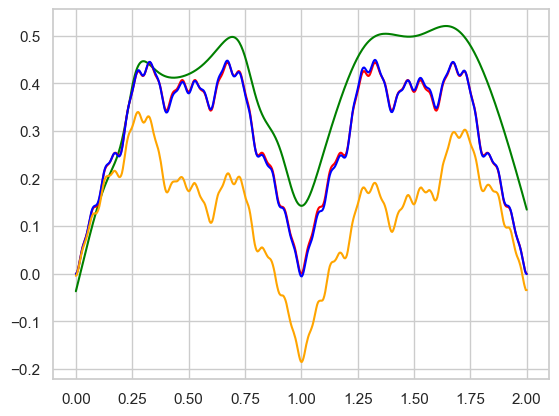

In [110]:
y_mlp = mlp(torch.tensor(t_eval, dtype=torch.float32, device=DEVICE).view(-1, 1)).cpu().detach().numpy()
y_fourier = fourier(torch.tensor(t_eval, dtype=torch.float32, device=DEVICE).view(-1, 1)).cpu().detach().numpy()

y_siren = siren(torch.tensor(t_eval, dtype=torch.float32, device=DEVICE).view(-1, 1)).cpu().detach().numpy()

plt.plot(t_eval, y_mlp, "green")
plt.plot(t_eval, y_fitted, "red")
plt.plot(t_eval, y_siren, "blue")
plt.plot(t_eval, y_fourier, "orange")

plt.show()